# Análise Zero Shot

## FA-KES

In [45]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [46]:
y_predicted_gem  = pd.read_csv('../../results/results_zero_shot_fakes_test.csv')
y_predicted_ds  = pd.read_csv('../../results/results_zero_shot_fakes_test_deep_seek.csv')
y_test = pd.read_csv('../../data/y_test_fakes.csv')

In [47]:
def normalize_labels(df, column):
    def clean_label(label):
        label = str(label).upper().strip()
        if "YES" in label:
            return "YES"
        return "NO"
    
    df[column] = df[column].apply(clean_label)
    return df

In [48]:
y_predicted_ds = normalize_labels(y_predicted_ds, "label")

In [49]:
y_predicted_gem.rename(columns={'label':'predicted'}, inplace= True)
y_predicted_ds.rename(columns={'label':'predicted'}, inplace= True)

In [50]:
# 0 FAKE 
# 1 REAL
results_map_gem = {'YES\r\n': 0, 'NO\r\n': 1}
results_map_ds = {'YES': 0, 'NO': 1}

In [51]:
df_gem = pd.concat([y_predicted_gem, y_test], axis=1)
df_ds = pd.concat([y_predicted_ds, y_test], axis=1)

In [52]:
df_gem.predicted = df_gem.predicted.map(results_map_gem)
df_ds.predicted = df_ds.predicted.map(results_map_ds)

In [53]:
print("\nRelatório de Classificação:\n", classification_report(df_gem.label, df_gem.predicted))


Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.51      0.63      0.56        62
           1       0.47      0.34      0.40        58

    accuracy                           0.49       120
   macro avg       0.49      0.49      0.48       120
weighted avg       0.49      0.49      0.48       120



In [54]:
print("\nRelatório de Classificação:\n", classification_report(df_ds.label, df_ds.predicted))


Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.29      0.03      0.06        62
           1       0.47      0.91      0.62        58

    accuracy                           0.46       120
   macro avg       0.38      0.47      0.34       120
weighted avg       0.37      0.46      0.33       120



### Matriz de Confusão

Matriz de Confusão:
[[39 23]
 [38 20]]


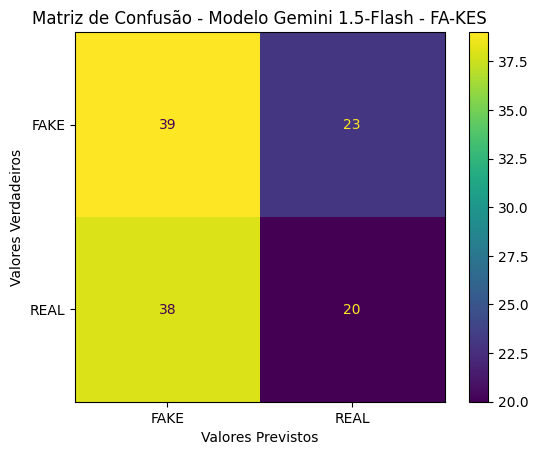

In [55]:
# Criando a matriz de confusão
matrix = confusion_matrix(df_gem.label, df_gem.predicted)

# Exibindo a matriz de confusão
print("Matriz de Confusão:")
print(matrix)

# Visualizando a matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=['FAKE', 'REAL'])
disp.plot()
plt.xlabel("Valores Previstos") 
plt.ylabel("Valores Verdadeiros") 
plt.title("Matriz de Confusão - Modelo Gemini 1.5-Flash - FA-KES")
plt.show()


Matriz de Confusão:
[[ 2 60]
 [ 5 53]]


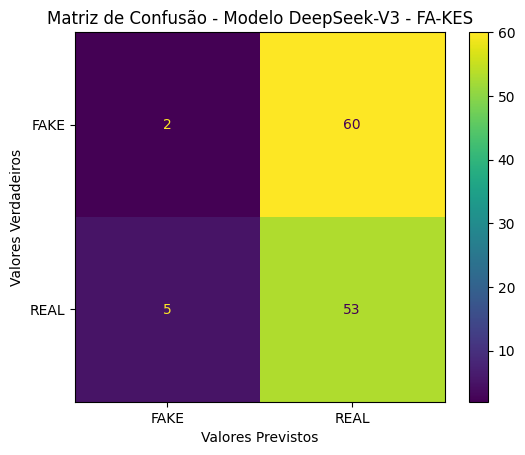

In [56]:
# Criando a matriz de confusão
matrix = confusion_matrix(df_ds.label, df_ds.predicted)

# Exibindo a matriz de confusão
print("Matriz de Confusão:")
print(matrix)

# Visualizando a matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=['FAKE', 'REAL'])
disp.plot()
plt.xlabel("Valores Previstos") 
plt.ylabel("Valores Verdadeiros") 
plt.title("Matriz de Confusão - Modelo DeepSeek-V3 - FA-KES")
plt.show()

## Fake.Br Corpus

In [57]:
y_predicted_gem = pd.read_csv('../../results/results_zero_shot_fake_br_test.csv')
y_predicted_ds  = pd.read_csv('../../results/results_zero_shot_fakebr_test_deep_seek.csv')
y_test = pd.read_csv('../../data/y_test_fakebr.csv')

In [58]:
y_predicted_ds = normalize_labels(y_predicted_ds, "label")

In [59]:
y_predicted_gem.rename(columns={'label':'predicted'}, inplace= True)
y_predicted_ds.rename(columns={'label':'predicted'}, inplace= True)

In [60]:
# 0 FAKE 
# 1 REAL
results_map_gem = {'YES\n': 0, 'NO\n': 1}
results_map_ds = {'YES': 0, 'NO': 1}

In [61]:
df_gem = pd.concat([y_predicted_gem, y_test], axis=1)
df_ds = pd.concat([y_predicted_ds, y_test], axis=1)

In [62]:
df_gem.predicted = df_gem.predicted.map(results_map_gem)
df_ds.predicted = df_ds.predicted.map(results_map_ds)

In [63]:
print("\nRelatório de Classificação:\n", classification_report(df_gem.label, df_gem.predicted))


Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.79      0.85      0.82        67
           1       0.79      0.72      0.75        53

    accuracy                           0.79       120
   macro avg       0.79      0.78      0.79       120
weighted avg       0.79      0.79      0.79       120



In [64]:
print("\nRelatório de Classificação:\n", classification_report(df_ds.label, df_ds.predicted))


Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.92      0.36      0.52        67
           1       0.54      0.96      0.69        53

    accuracy                           0.62       120
   macro avg       0.73      0.66      0.61       120
weighted avg       0.76      0.62      0.59       120



### Matriz de confusão

Matriz de Confusão:
[[57 10]
 [15 38]]


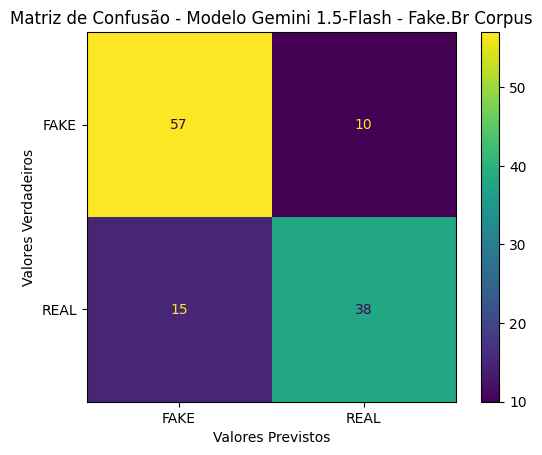

In [65]:
# Criando a matriz de confusão
matrix = confusion_matrix(df_gem.label, df_gem.predicted)

# Exibindo a matriz de confusão
print("Matriz de Confusão:")
print(matrix)

# Visualizando a matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=['FAKE', 'REAL'])
disp.plot()
plt.xlabel("Valores Previstos") 
plt.ylabel("Valores Verdadeiros") 
plt.title("Matriz de Confusão - Modelo Gemini 1.5-Flash - Fake.Br Corpus")
plt.show()

Matriz de Confusão:
[[24 43]
 [ 2 51]]


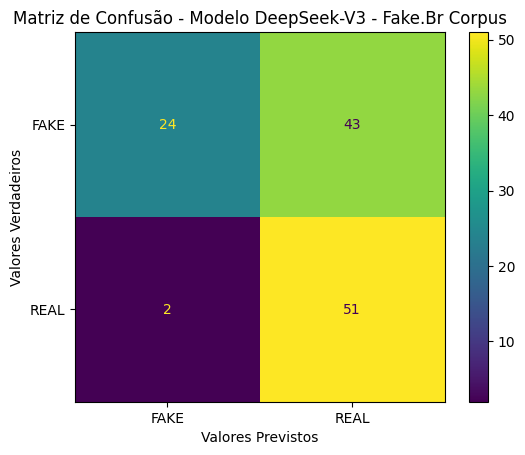

In [66]:
# Criando a matriz de confusão
matrix = confusion_matrix(df_ds.label, df_ds.predicted)

# Exibindo a matriz de confusão
print("Matriz de Confusão:")
print(matrix)

# Visualizando a matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=['FAKE', 'REAL'])
disp.plot()
plt.xlabel("Valores Previstos") 
plt.ylabel("Valores Verdadeiros") 
plt.title("Matriz de Confusão - Modelo DeepSeek-V3 - Fake.Br Corpus")
plt.show()